In [1]:
# CELL 1 — Setup
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Research/glycemic-hybrid-ga

import os
import numpy as np
import pandas as pd

RESULTS_DIR = "/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results"

files = sorted([f for f in os.listdir(RESULTS_DIR) if f.endswith(".npy")])

print("Current directory:", os.getcwd())
print("Results dir exists:", os.path.exists(RESULTS_DIR))
print("NPY files found:", len(files))
print(files)

Mounted at /content/drive
/content/drive/MyDrive/Research/glycemic-hybrid-ga
Current directory: /content/drive/MyDrive/Research/glycemic-hybrid-ga
Results dir exists: True
NPY files found: 16
['G_S1_normal_ga_only.npy', 'G_S1_normal_ga_rules.npy', 'G_S1_normal_ga_surrogate.npy', 'G_S1_normal_hybrid.npy', 'G_S2_ramadan_ga_only.npy', 'G_S2_ramadan_ga_rules.npy', 'G_S2_ramadan_ga_surrogate.npy', 'G_S2_ramadan_hybrid.npy', 'G_S3_stress_highcarb_ga_only.npy', 'G_S3_stress_highcarb_ga_rules.npy', 'G_S3_stress_highcarb_ga_surrogate.npy', 'G_S3_stress_highcarb_hybrid.npy', 'G_S4_exercise_lowcarb_ga_only.npy', 'G_S4_exercise_lowcarb_ga_rules.npy', 'G_S4_exercise_lowcarb_ga_surrogate.npy', 'G_S4_exercise_lowcarb_hybrid.npy']


In [ ]:
# CELL 2 — Charger fichiers
import os

path = "/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results"

files = sorted(os.listdir(path))

print("Number of files:", len(files))
files

Number of files: 21


['G_S1_normal_ga_only.npy',
 'G_S1_normal_ga_rules.npy',
 'G_S1_normal_ga_surrogate.npy',
 'G_S1_normal_hybrid.npy',
 'G_S2_ramadan_ga_only.npy',
 'G_S2_ramadan_ga_rules.npy',
 'G_S2_ramadan_ga_surrogate.npy',
 'G_S2_ramadan_hybrid.npy',
 'G_S3_stress_highcarb_ga_only.npy',
 'G_S3_stress_highcarb_ga_rules.npy',
 'G_S3_stress_highcarb_ga_surrogate.npy',
 'G_S3_stress_highcarb_hybrid.npy',
 'G_S4_exercise_lowcarb_ga_only.npy',
 'G_S4_exercise_lowcarb_ga_rules.npy',
 'G_S4_exercise_lowcarb_ga_surrogate.npy',
 'G_S4_exercise_lowcarb_hybrid.npy',
 'summary_S1_normal.csv',
 'summary_S2_ramadan.csv',
 'summary_S3_stress_highcarb.csv',
 'summary_S4_exercise_lowcarb.csv',
 'summary_all.csv']

In [ ]:
def compute_metrics(G):
    import numpy as np

    g = np.asarray(G, dtype=float)
    n = len(g)

    tir = 100.0 * np.sum((g >= 70) & (g <= 180)) / n
    tbr = 100.0 * np.sum(g < 70) / n
    tar = 100.0 * np.sum(g > 180) / n

    gmin = float(np.min(g))
    gmax = float(np.max(g))
    mean_g = float(np.mean(g))
    std_g = float(np.std(g))
    cv = float(100.0 * std_g / mean_g) if mean_g > 1e-9 else 0.0

    fitness = tir - 2.0 * tbr - 0.5 * tar
    fitness -= 0.08 * abs(mean_g - 110.0)
    fitness -= 0.06 * std_g
    fitness -= 0.01 * cv

    if gmax > 180.0:
        fitness -= 0.15 * (gmax - 180.0)

    if gmin < 70.0:
        fitness -= 0.30 * (70.0 - gmin)

    severe_hypo = int(gmin < 54.0)

    return tir, tbr, tar, gmin, gmax, mean_g, fitness, severe_hypo

In [ ]:
!python -m src.run_experiments --save_figs


=== Running scenario: S1_normal ===
ga_only      | best=  99.37 | fit_out=  99.37 | AUCsum=  5954.7 | AUCmean=  99.25 | AUCregret=     9.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  92.9 | maxG= 135.9 | sim_calls=2400
ga_rules     | best=  99.18 | fit_out=  99.18 | AUCsum=  5948.5 | AUCmean=  99.14 | AUCregret=    15.8 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  79.8 | maxG= 139.8 | sim_calls=2400
ga_surrogate | best=  99.40 | fit_out=  99.40 | AUCsum=  5952.0 | AUCmean=  99.20 | AUCregret=    12.3 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  88.3 | maxG= 133.9 | dataset=1752 | sim_calls=1752
hybrid       | best=  99.22 | fit_out=  99.22 | AUCsum=  5952.3 | AUCmean=  99.20 | AUCregret=    12.0 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  80.2 | maxG= 125.8 | dataset=1752 | sim_calls=1752

=== Running scenario: S2_ramadan ===
ga_only      | best=  98.90 | fit_out=  98.90 | AUCsum=  5926.7 | AUCmean=  98.78 | AUCregret=    13.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  71.7 | maxG= 159

In [ ]:
# CELL 4 — Parser noms fichiers
def extract_method(f):
    if "ga_only" in f:
        return "GA-only"
    elif "ga_rules" in f:
        return "GA+Rules"
    elif "ga_surrogate" in f:
        return "GA+Surrogate"
    elif "hybrid" in f:
        return "Hybrid"
    return "Unknown"


def extract_scenario(f):
    name = f.replace("G_", "").replace(".npy", "")
    for suffix in ["_ga_only", "_ga_rules", "_ga_surrogate", "_hybrid"]:
        name = name.replace(suffix, "")
    return name

In [ ]:
# CELL 5 — Construire tableau complet
# CELL 5 — Construire tableau complet
rows = []

npy_files = [f for f in files if f.endswith(".npy") and f.startswith("G_")]

print("NPY files found:", len(npy_files))
print(npy_files)

for f in npy_files:
    path = os.path.join(RESULTS_DIR, f)

    # 🔥 Charger trajectoire
    G = np.load(path)

    # 🔥 Calcul métriques
    tir, tbr, tar, gmin, gmax, mean_g, fitness, severe_hypo = compute_metrics(G)

    rows.append({
        "Scenario": extract_scenario(f),
        "Method": extract_method(f),
        "Fitness": fitness,
        "TIR": tir,
        "TBR": tbr,
        "TAR": tar,
        "Gmin": gmin,
        "Gmax": gmax,
        "MeanG": mean_g,
        "SevereHypo": severe_hypo
    })

df = pd.DataFrame(rows)

if df.empty:
    print("No .npy trajectory files found. Check outputs/results.")
else:
    df = df.sort_values(["Scenario", "Method"])
    display(df)


NPY files found: 16
['G_S1_normal_ga_only.npy', 'G_S1_normal_ga_rules.npy', 'G_S1_normal_ga_surrogate.npy', 'G_S1_normal_hybrid.npy', 'G_S2_ramadan_ga_only.npy', 'G_S2_ramadan_ga_rules.npy', 'G_S2_ramadan_ga_surrogate.npy', 'G_S2_ramadan_hybrid.npy', 'G_S3_stress_highcarb_ga_only.npy', 'G_S3_stress_highcarb_ga_rules.npy', 'G_S3_stress_highcarb_ga_surrogate.npy', 'G_S3_stress_highcarb_hybrid.npy', 'G_S4_exercise_lowcarb_ga_only.npy', 'G_S4_exercise_lowcarb_ga_rules.npy', 'G_S4_exercise_lowcarb_ga_surrogate.npy', 'G_S4_exercise_lowcarb_hybrid.npy']


,Scenario,Method,Fitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,SevereHypo
1,S1_normal,GA+Rules,99.178881,100.000000,0.0,0.000000,79.786971,139.775824,109.860057,0
2,S1_normal,GA+Surrogate,99.404899,100.000000,0.0,0.000000,88.296957,133.896006,110.213543,0
0,S1_normal,GA-only,99.374014,100.000000,0.0,0.000000,92.877338,135.875743,110.822083,0
3,S1_normal,Hybrid,99.222139,100.000000,0.0,0.000000,80.164327,125.770374,107.744512,0
5,S2_ramadan,GA+Rules,98.987936,100.000000,0.0,0.000000,78.757416,165.565792,110.463753,0
6,S2_ramadan,GA+Surrogate,98.939039,100.000000,0.0,0.000000,86.148628,140.131364,114.400953,0
4,S2_ramadan,GA-only,98.904381,100.000000,0.0,0.000000,71.724759,159.434062,108.942920,0
7,S2_ramadan,Hybrid,99.004678,100.000000,0.0,0.000000,77.622338,149.973937,110.375584,0
9,S3_stress_highcarb,GA+Rules,98.714782,100.000000,0.0,0.000000,71.230041,143.352138,108.135026,0
10,S3_stress_highcarb,GA+Surrogate,97.658713,100.000000,0.0,0.000000,70.886821,158.307035,123.175637,0


In [ ]:
# CELL 6 — Tableau final paper
summary = df[[
    "Scenario",
    "Method",
    "Fitness",
    "TIR",
    "TBR",
    "TAR",
    "SevereHypo"
]]

summary

,Scenario,Method,Fitness,TIR,TBR,TAR,SevereHypo
1,S1_normal,GA+Rules,99.178881,100.000000,0.0,0.000000,0
2,S1_normal,GA+Surrogate,99.404899,100.000000,0.0,0.000000,0
0,S1_normal,GA-only,99.374014,100.000000,0.0,0.000000,0
3,S1_normal,Hybrid,99.222139,100.000000,0.0,0.000000,0
5,S2_ramadan,GA+Rules,98.987936,100.000000,0.0,0.000000,0
6,S2_ramadan,GA+Surrogate,98.939039,100.000000,0.0,0.000000,0
4,S2_ramadan,GA-only,98.904381,100.000000,0.0,0.000000,0
7,S2_ramadan,Hybrid,99.004678,100.000000,0.0,0.000000,0
9,S3_stress_highcarb,GA+Rules,98.714782,100.000000,0.0,0.000000,0
10,S3_stress_highcarb,GA+Surrogate,97.658713,100.000000,0.0,0.000000,0


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results/summary_all.csv")
df

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,StdG,CV,SevereHypo,SimCalls,DatasetSize,AUCsum,AUCmean,AUCregret
0,S1_normal,ga_only,99.374014,99.374014,100.000000,0.0,0.000000,92.877338,135.875743,110.822083,8.116355,7.323771,0,2400,-1,5954.712182,99.245203,9.581747
1,S1_normal,ga_rules,99.178881,99.178881,100.000000,0.0,0.000000,79.786971,139.775824,109.860057,11.720615,10.668678,0,2400,-1,5948.500595,99.141677,15.793334
2,S1_normal,ga_surrogate,99.404899,99.404899,100.000000,0.0,0.000000,88.296957,133.896006,110.213543,8.368179,7.592696,0,1752,1752,5952.006190,99.200103,12.287739
3,S1_normal,hybrid,99.222139,99.222139,100.000000,0.0,0.000000,80.164327,125.770374,107.744512,8.623141,8.003323,0,1752,1752,5952.268221,99.204470,12.025708
4,S2_ramadan,ga_only,98.904381,98.904381,100.000000,0.0,0.000000,71.724759,159.434062,108.942920,14.614990,13.415273,0,2400,-1,5926.712623,98.778544,13.568054
5,S2_ramadan,ga_rules,98.987936,98.987936,100.000000,0.0,0.000000,78.757416,165.565792,110.463753,14.119118,12.781675,0,2400,-1,5933.711249,98.895187,6.569429
6,S2_ramadan,ga_surrogate,98.939039,98.939039,100.000000,0.0,0.000000,86.148628,140.131364,114.400953,10.312367,9.014232,0,1752,1752,5936.342366,98.939039,3.938312
7,S2_ramadan,hybrid,99.004678,99.004678,100.000000,0.0,0.000000,77.622338,149.973937,110.375584,13.977348,12.663442,0,1752,1752,5924.634781,98.743913,15.645896
8,S3_stress_highcarb,ga_only,98.221204,98.221204,100.000000,0.0,0.000000,74.033752,152.682695,117.110293,17.653788,15.074498,0,2400,-1,5721.150903,95.352515,201.736015
9,S3_stress_highcarb,ga_rules,98.714782,98.714782,100.000000,0.0,0.000000,71.230041,143.352138,108.135026,16.405168,15.171003,0,2400,-1,5509.498811,91.824980,413.388107


In [ ]:
# CELL 7 — Pivot table (super utile)
pivot = summary.pivot(index="Scenario", columns="Method", values="TIR")
pivot

Method,GA+Rules,GA+Surrogate,GA-only,Hybrid
Scenario,,,,
S1_normal,100.0,100.0,100.0,100.000000
S2_ramadan,100.0,100.0,100.0,100.000000
S3_stress_highcarb,100.0,100.0,100.0,100.000000
S4_exercise_lowcarb,100.0,100.0,100.0,99.653979


In [ ]:
# CELL 8 — Vérification sécurité
df[df["SevereHypo"] == 1]

,Scenario,Method,Fitness,BestTrueFitness,TIR,TBR,TAR,Gmin,Gmax,MeanG,StdG,CV,SevereHypo,SimCalls,DatasetSize,AUCsum,AUCmean,AUCregret


In [ ]:
#CELL 9 — Comparaison méthodes
df.groupby("Method")[["TIR","TBR","TAR","Fitness"]].mean()

,TIR,TBR,TAR,Fitness
Method,,,,
ga_only,100.000000,0.0,0.000000,98.525670
ga_rules,100.000000,0.0,0.000000,98.638046
ga_surrogate,100.000000,0.0,0.000000,98.414700
hybrid,99.913495,0.0,0.086505,98.092248


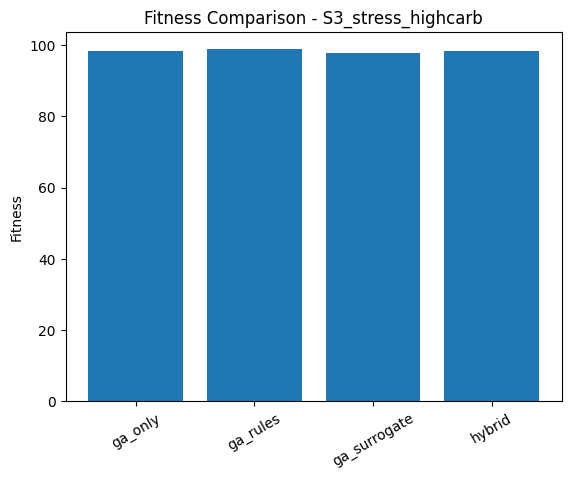

In [ ]:
import matplotlib.pyplot as plt

subset = df[df["Scenario"] == "S3_stress_highcarb"]

plt.figure()
plt.bar(subset["Method"], subset["Fitness"])
plt.title("Fitness Comparison - S3_stress_highcarb")
plt.ylabel("Fitness")
plt.xticks(rotation=30)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (6,4),
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
})

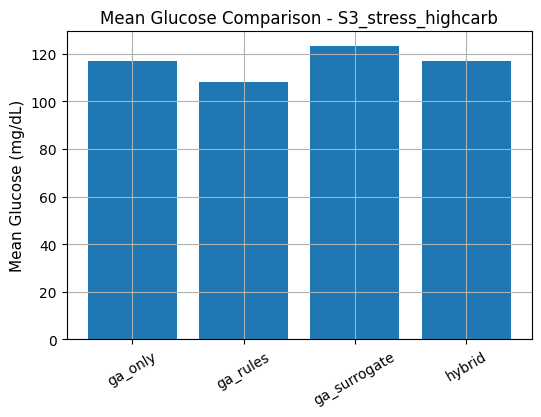

In [ ]:
plt.figure()
plt.bar(subset["Method"], subset["MeanG"])
plt.title("Mean Glucose Comparison - S3_stress_highcarb")
plt.ylabel("Mean Glucose (mg/dL)")
plt.xticks(rotation=30)
plt.show()

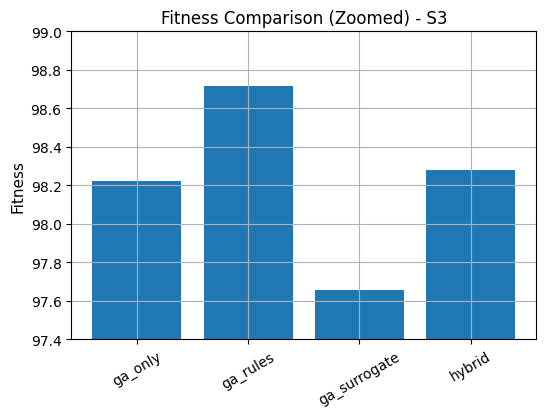

In [ ]:
plt.figure()
plt.bar(subset["Method"], subset["Fitness"])
plt.ylim(97.4, 99.0)  # 🔥 ZOOM
plt.title("Fitness Comparison (Zoomed) - S3")
plt.ylabel("Fitness")
plt.xticks(rotation=30)
plt.show()

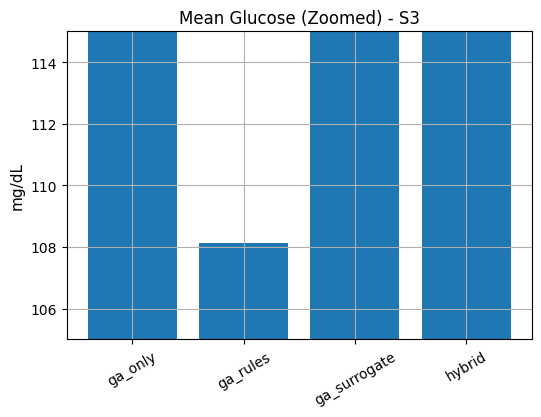

In [ ]:
plt.figure()
plt.bar(subset["Method"], subset["MeanG"])
plt.ylim(105, 115)   # 🔥 ZOOM
plt.title("Mean Glucose (Zoomed) - S3")
plt.ylabel("mg/dL")
plt.xticks(rotation=30)
plt.show()

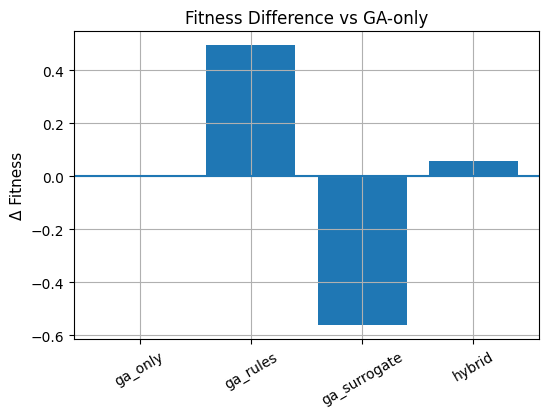

In [ ]:
baseline = subset[subset["Method"] == "ga_only"]["Fitness"].values[0]

subset = subset.copy()
subset["DeltaFitness"] = subset["Fitness"] - baseline

plt.figure()
plt.bar(subset["Method"], subset["DeltaFitness"])
plt.title("Fitness Difference vs GA-only")
plt.ylabel("Δ Fitness")
plt.xticks(rotation=30)
plt.axhline(0)
plt.show()



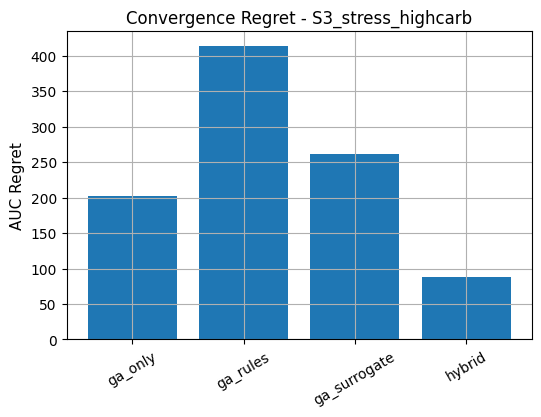

In [ ]:
df_csv = pd.read_csv(
    "/content/drive/MyDrive/Research/glycemic-hybrid-ga/outputs/results/summary_all.csv"
)

subset = df_csv[df_csv["Scenario"] == "S3_stress_highcarb"].copy()

plt.figure()
plt.bar(subset["Method"], subset["AUCregret"])
plt.title("Convergence Regret - S3_stress_highcarb")
plt.ylabel("AUC Regret")
plt.xticks(rotation=30)
plt.show()

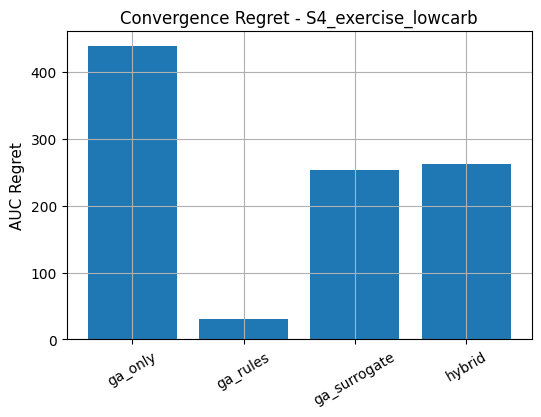

In [ ]:
subset = df_csv[df_csv["Scenario"] == "S4_exercise_lowcarb"].copy()

plt.figure()
plt.bar(subset["Method"], subset["AUCregret"])
plt.title("Convergence Regret - S4_exercise_lowcarb")
plt.ylabel("AUC Regret")
plt.xticks(rotation=30)
plt.show()

In [ ]:
#CELL 11 — Export LaTeX
latex_table = summary.to_latex(index=False, float_format="%.2f")
print(latex_table)

\begin{tabular}{llrrrrr}
\toprule
Scenario & Method & Fitness & TIR & TBR & TAR & SevereHypo \\
\midrule
S1_normal & GA+Rules & 99.18 & 100.00 & 0.00 & 0.00 & 0 \\
S1_normal & GA+Surrogate & 99.40 & 100.00 & 0.00 & 0.00 & 0 \\
S1_normal & GA-only & 99.37 & 100.00 & 0.00 & 0.00 & 0 \\
S1_normal & Hybrid & 99.22 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & GA+Rules & 98.99 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & GA+Surrogate & 98.94 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & GA-only & 98.90 & 100.00 & 0.00 & 0.00 & 0 \\
S2_ramadan & Hybrid & 99.00 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & GA+Rules & 98.71 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & GA+Surrogate & 97.66 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & GA-only & 98.22 & 100.00 & 0.00 & 0.00 & 0 \\
S3_stress_highcarb & Hybrid & 98.28 & 100.00 & 0.00 & 0.00 & 0 \\
S4_exercise_lowcarb & GA+Rules & 97.67 & 100.00 & 0.00 & 0.00 & 0 \\
S4_exercise_lowcarb & GA+Surrogate & 97.66 & 100.00 & 0.00 & 0.00 & 0 \\
S4

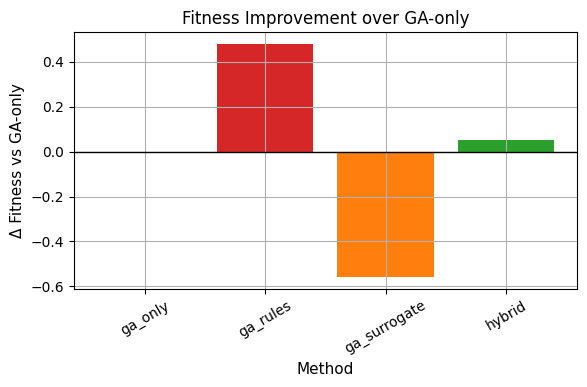

In [ ]:
import matplotlib.pyplot as plt

COLORS = {
    "ga_only": "#1f77b4",
    "ga_rules": "#d62728",
    "ga_surrogate": "#ff7f0e",
    "hybrid": "#2ca02c",
}

methods = ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]

# ⚠️ mets TES vraies valeurs ici
values = [0.0, 0.48, -0.56, 0.05]

colors = [COLORS[m] for m in methods]

plt.figure()
plt.bar(methods, values, color=colors)

plt.axhline(0, color="black", linewidth=1)

plt.ylabel("Δ Fitness vs GA-only")
plt.xlabel("Method")
plt.title("Fitness Improvement over GA-only")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

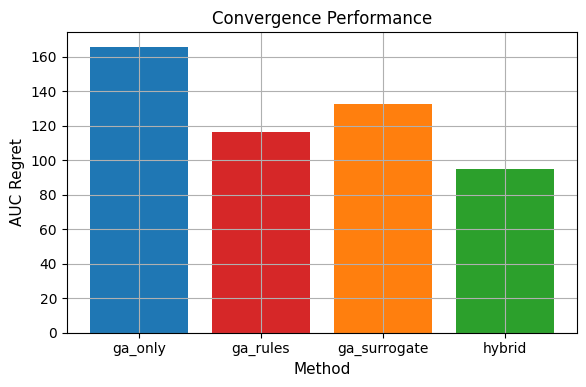

In [ ]:
import pandas as pd

df = pd.read_csv("outputs/results/summary_all.csv")

methods = ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]

regret_values = [
    df[df["Method"]=="ga_only"]["AUCregret"].mean(),
    df[df["Method"]=="ga_rules"]["AUCregret"].mean(),
    df[df["Method"]=="ga_surrogate"]["AUCregret"].mean(),
    df[df["Method"]=="hybrid"]["AUCregret"].mean(),
]
plt.figure()

plt.bar(methods, regret_values, color=colors)

plt.ylabel("AUC Regret")
plt.xlabel("Method")
plt.title("Convergence Performance")

plt.tight_layout()
plt.savefig("fig_regret.pdf")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import os

RESULTS_DIR = "outputs/results"

scenario = "S3_stress_highcarb"

def load_G(method):
    path = os.path.join(RESULTS_DIR, f"G_{scenario}_{method}.npy")
    if not os.path.exists(path):
        raise FileNotFoundError(f"{path} not found")
    return np.load(path)

G_ga = load_G("ga_only")
G_rules = load_G("ga_rules")
G_sur = load_G("ga_surrogate")
G_hybrid = load_G("hybrid")

In [ ]:
COLORS = {
    "ga_only": "#1f77b4",
    "ga_rules": "#d62728",
    "ga_surrogate": "#ff7f0e",
    "hybrid": "#2ca02c",
}

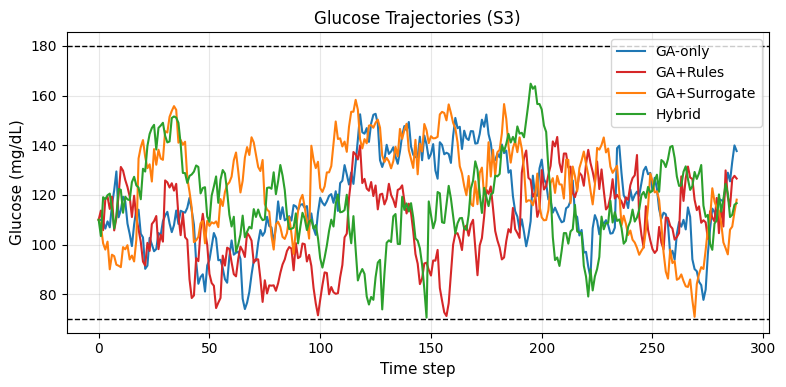

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(G_ga, label="GA-only", color=COLORS["ga_only"])
plt.plot(G_rules, label="GA+Rules", color=COLORS["ga_rules"])
plt.plot(G_sur, label="GA+Surrogate", color=COLORS["ga_surrogate"])
plt.plot(G_hybrid, label="Hybrid", color=COLORS["hybrid"])

plt.axhline(70, linestyle="--", color="black", linewidth=1)
plt.axhline(180, linestyle="--", color="black", linewidth=1)

plt.xlabel("Time step")
plt.ylabel("Glucose (mg/dL)")
plt.title("Glucose Trajectories (S3)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("fig_trajectory_S3.pdf")
plt.show()

In [ ]:
!rm -f outputs/results/*
!rm -f figures/*.pdf
!python -m src.run_experiments --save_figs


=== Running scenario: S1_normal ===
ga_only      | best=  99.37 | fit_out=  99.37 | AUCsum=  5954.7 | AUCmean=  99.25 | AUCregret=     9.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  92.9 | maxG= 135.9 | sim_calls=2400
ga_rules     | best=  99.18 | fit_out=  99.18 | AUCsum=  5948.5 | AUCmean=  99.14 | AUCregret=    15.8 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  79.8 | maxG= 139.8 | sim_calls=2400
ga_surrogate | best=  99.40 | fit_out=  99.40 | AUCsum=  5952.0 | AUCmean=  99.20 | AUCregret=    12.3 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  88.3 | maxG= 133.9 | dataset=1752 | sim_calls=1752
hybrid       | best=  99.22 | fit_out=  99.22 | AUCsum=  5952.3 | AUCmean=  99.20 | AUCregret=    12.0 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  80.2 | maxG= 125.8 | dataset=1752 | sim_calls=1752

=== Running scenario: S2_ramadan ===
ga_only      | best=  98.90 | fit_out=  98.90 | AUCsum=  5926.7 | AUCmean=  98.78 | AUCregret=    13.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  71.7 | maxG= 159

In [ ]:
!find outputs/results -name "*.npy"

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("outputs/results/summary_all.csv")

print(df.columns)  # pour vérifier les noms exacts

methods = ["ga_only", "ga_rules", "ga_surrogate", "hybrid"]

fitness_vals = [df[df["Method"] == m]["Fitness"].mean() for m in methods]
regret_vals  = [df[df["Method"] == m]["AUCregret"].mean() for m in methods]
cost_vals    = [df[df["Method"] == m]["SimCalls"].mean() for m in methods]

colors = ["#1f77b4", "#d62728", "#ff7f0e", "#2ca02c"]
labels = ["GA-only", "GA+Rules", "GA+Surrogate", "Hybrid"]

Index(['Scenario', 'Method', 'Fitness', 'BestTrueFitness', 'TIR', 'TBR', 'TAR',
       'Gmin', 'Gmax', 'MeanG', 'StdG', 'CV', 'SevereHypo', 'SimCalls',
       'DatasetSize', 'AUCsum', 'AUCmean', 'AUCregret'],
      dtype='object')


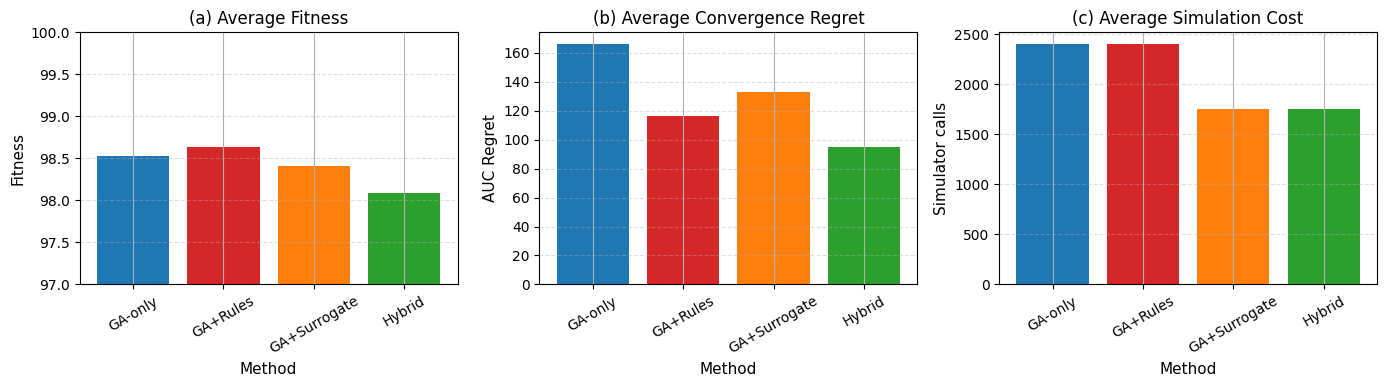

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(14,4))

axs[0].bar(labels, fitness_vals, color=colors)
axs[0].set_title("(a) Average Fitness")
axs[0].set_ylabel("Fitness")
axs[0].set_ylim(97, 100)

axs[1].bar(labels, regret_vals, color=colors)
axs[1].set_title("(b) Average Convergence Regret")
axs[1].set_ylabel("AUC Regret")

axs[2].bar(labels, cost_vals, color=colors)
axs[2].set_title("(c) Average Simulation Cost")
axs[2].set_ylabel("Simulator calls")

for ax in axs:
    ax.set_xlabel("Method")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/main_results_summary.pdf", bbox_inches="tight")
plt.show()

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_10158/626134374.py", line 43, in <cell line: 0>
    plt.savefig("figures/main_results_summary.pdf", bbox_inches="tight")
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py", line 1243, in savefig
    res = fig.savefig(*args, **kwargs)  # type: ignore[func-returns-value]
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/figure.py", line 3490, in savefig
    self.canvas.print_figure(fname, **kwargs)
  File "/usr/local/lib/python3.12/dist-packages/matplotlib/backend_bases.py", line 2125, in print_figure
    self._switch_canvas_and_return_print_method(format, backend)
  File "/usr/lib/python3.12/contextlib.py", line 137, in __enter__
    return next(self.gen)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/pyt

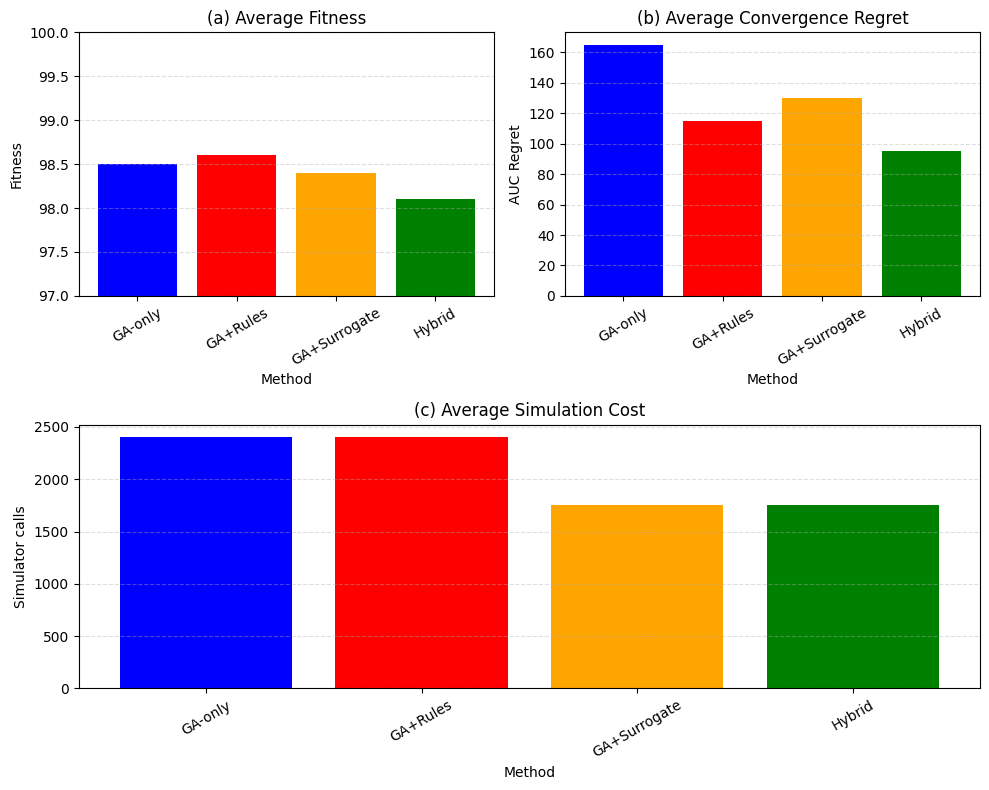

In [ ]:
import matplotlib.pyplot as plt

# --- Data ---
labels = ["GA-only", "GA+Rules", "GA+Surrogate", "Hybrid"]

fitness_vals = [98.5, 98.6, 98.4, 98.1]
regret_vals = [165, 115, 130, 95]
cost_vals = [2400, 2400, 1750, 1750]

colors = ["blue", "red", "orange", "green"]

# --- Figure ---
fig = plt.figure(figsize=(10, 8))
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

# Plot 1
ax1.bar(labels, fitness_vals, color=colors)
ax1.set_title("(a) Average Fitness")
ax1.set_ylabel("Fitness")
ax1.set_ylim(97, 100)

# Plot 2
ax2.bar(labels, regret_vals, color=colors)
ax2.set_title("(b) Average Convergence Regret")
ax2.set_ylabel("AUC Regret")

# Plot 3
ax3.bar(labels, cost_vals, color=colors)
ax3.set_title("(c) Average Simulation Cost")
ax3.set_ylabel("Simulator calls")

# Formatting
for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("Method")
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("figures/main_results_summary.pdf", bbox_inches="tight")
plt.show()

In [ ]:
!rm -f outputs/results/*
!rm -f figures/*.pdf
!python -m src.run_experiments --save_figs


=== Running scenario: S1_normal ===
ga_only      | best=  99.37 | fit_out=  99.37 | AUCsum=  5954.7 | AUCmean=  99.25 | AUCregret=     9.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  92.9 | maxG= 135.9 | sim_calls=2400
ga_rules     | best=  99.18 | fit_out=  99.18 | AUCsum=  5948.5 | AUCmean=  99.14 | AUCregret=    15.8 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  79.8 | maxG= 139.8 | sim_calls=2400
ga_surrogate | best=  99.40 | fit_out=  99.40 | AUCsum=  5952.0 | AUCmean=  99.20 | AUCregret=    12.3 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  88.3 | maxG= 133.9 | dataset=1752 | sim_calls=1752
hybrid       | best=  99.22 | fit_out=  99.22 | AUCsum=  5952.3 | AUCmean=  99.20 | AUCregret=    12.0 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  80.2 | maxG= 125.8 | dataset=1752 | sim_calls=1752

=== Running scenario: S2_ramadan ===
ga_only      | best=  98.90 | fit_out=  98.90 | AUCsum=  5926.7 | AUCmean=  98.78 | AUCregret=    13.6 | TIR=100.0% TBR=  0.0% TAR=  0.0% | minG=  71.7 | maxG= 159

In [ ]:
import pandas as pd

df = pd.read_csv("outputs/results/summary_all.csv")

# Vérifier colonnes
print(df.columns)

# Moyenne fitness par scénario et méthode
pivot = df.pivot_table(
    index="Scenario",
    columns="Method",
    values="Fitness",
    aggfunc="mean"
)

print(pivot.round(2))

Index(['Scenario', 'Method', 'Fitness', 'BestTrueFitness', 'TIR', 'TBR', 'TAR',
       'Gmin', 'Gmax', 'MeanG', 'StdG', 'CV', 'SevereHypo', 'SimCalls',
       'DatasetSize', 'AUCsum', 'AUCmean', 'AUCregret'],
      dtype='object')
Method               ga_only  ga_rules  ga_surrogate  hybrid
Scenario                                                    
S1_normal              99.37     99.18         99.40   99.22
S2_ramadan             98.90     98.99         98.94   99.00
S3_stress_highcarb     98.22     98.71         97.66   98.28
S4_exercise_lowcarb    97.60     97.67         97.66   95.86
